In [27]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from src.data.preprocessing import prepare_dataset
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
from src.data.segmentation_dataset import BrainMRISegmentationDataset
from src.models.unet import build_unet
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import cv2

In [2]:
DATA_DIR = "../data/raw/kaggle_3m"
df = prepare_dataset(DATA_DIR)

In [3]:
print(f"Total rows: {len(df)}")
df.head()

Total rows: 3929


,patient_id,image_path,mask_path,has_tumor
0,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,False
1,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,True
2,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,True
3,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,True
4,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,True


In [4]:
unique_patients = df["patient_id"].unique()

train_patients, temp_patients = train_test_split(
    unique_patients, test_size=0.3, random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.5, random_state=42
)

train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)
test_df = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)

print(f"Train images: {len(train_df)}")
print(f"Val images: {len(val_df)}")
print(f"Test images: {len(test_df)}")

Train images: 2750
Val images: 618
Test images: 561


In [9]:
train_seg_dataset = BrainMRISegmentationDataset(train_df, image_size=128)

print(f"Number of samples: {len(train_seg_dataset)}")

image, mask = train_seg_dataset[13]
print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Mask unique values: {torch.unique(mask)}")

Number of samples: 2750
Image shape: torch.Size([3, 128, 128])
Mask shape: torch.Size([1, 128, 128])
Mask unique values: tensor([0.])


In [10]:
tumor_rows = train_df[train_df["has_tumor"] == True]
sample_idx = tumor_rows.index[5]

image2, mask2 = train_seg_dataset[sample_idx]

print(f"Mask unique values: {torch.unique(mask2)}")
print(f"Tumor pixel count: {mask2.sum().item()}")

Mask unique values: tensor([0., 1.])
Tumor pixel count: 256.0


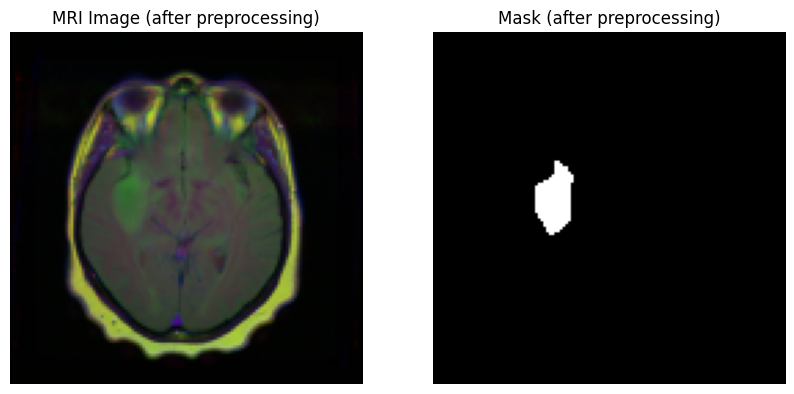

In [13]:
image2_np = image2.numpy()
image2_np = np.transpose(image2_np, (1, 2, 0))

mask2_np = mask2.numpy().squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image2_np)
axes[0].set_title("MRI Image (after preprocessing)")
axes[0].axis("off")

axes[1].imshow(mask2_np, cmap="gray")
axes[1].set_title("Mask (after preprocessing)")
axes[1].axis("off")

plt.show()

In [16]:
val_seg_dataset = BrainMRISegmentationDataset(val_df, image_size=128)
test_seg_dataset = BrainMRISegmentationDataset(test_df, image_size=128)

BATCH_SIZE = 16

train_seg_loader = DataLoader(train_seg_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_seg_loader = DataLoader(val_seg_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_seg_loader = DataLoader(test_seg_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_seg_loader)}")
print(f"Val batches: {len(val_seg_loader)}")
print(f"Test batches: {len(test_seg_loader)}")

Train batches: 172
Val batches: 39
Test batches: 36


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [20]:
unet_model = build_unet(encoder_name="resnet34", in_channels=3, out_channels=1)
unet_model = unet_model.to(device)

sample_images, sample_masks = next(iter(train_seg_loader))
sample_images = sample_images.to(device)

print(f"Input shape: {sample_images.shape}")

output = unet_model(sample_images)

print(f"Output shape: {output.shape}")
print(f"Mask shape: {sample_masks.shape}")

Input shape: torch.Size([16, 3, 128, 128])


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.0.1+cu118
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Output shape: torch.Size([16, 1, 128, 128])
Mask shape: torch.Size([16, 1, 128, 128])


In [21]:
criterion_seg = smp.losses.DiceLoss(mode="binary")

In [22]:
optimizer_seg = torch.optim.Adam(unet_model.parameters(), lr=0.0001)

In [23]:
def evaluate_segmentation(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    return avg_loss

In [24]:
NUM_EPOCHS_SEG = 15
best_val_loss_seg = float("inf")
checkpoint_path_seg = "../models/segmentation/weights/unet_best.pt"

train_losses_seg = []
val_losses_seg = []

for epoch in range(NUM_EPOCHS_SEG):
    unet_model.train()
    running_loss = 0.0

    for images, masks in train_seg_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer_seg.zero_grad()
        outputs = unet_model(images)
        loss = criterion_seg(outputs, masks)
        loss.backward()
        optimizer_seg.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_seg_loader)
    val_loss = evaluate_segmentation(unet_model, val_seg_loader, criterion_seg, device)

    train_losses_seg.append(train_loss)
    val_losses_seg.append(val_loss)

    if val_loss < best_val_loss_seg:
        best_val_loss_seg = val_loss
        torch.save(unet_model.state_dict(), checkpoint_path_seg)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_SEG} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}  Saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_SEG} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch 1/15 - Train Loss: 0.9279 - Val Loss: 0.6364  Saved
Epoch 2/15 - Train Loss: 0.7311 - Val Loss: 0.4691  Saved
Epoch 3/15 - Train Loss: 0.4213 - Val Loss: 0.3096  Saved
Epoch 4/15 - Train Loss: 0.2385 - Val Loss: 0.2895  Saved
Epoch 5/15 - Train Loss: 0.1724 - Val Loss: 0.2305  Saved
Epoch 6/15 - Train Loss: 0.1475 - Val Loss: 0.2395
Epoch 7/15 - Train Loss: 0.1334 - Val Loss: 0.2817
Epoch 8/15 - Train Loss: 0.1241 - Val Loss: 0.2497
Epoch 9/15 - Train Loss: 0.1187 - Val Loss: 0.2341
Epoch 10/15 - Train Loss: 0.1042 - Val Loss: 0.2569
Epoch 11/15 - Train Loss: 0.1060 - Val Loss: 0.2065  Saved
Epoch 12/15 - Train Loss: 0.1077 - Val Loss: 0.2843
Epoch 13/15 - Train Loss: 0.1095 - Val Loss: 0.2890
Epoch 14/15 - Train Loss: 0.0921 - Val Loss: 0.2966
Epoch 15/15 - Train Loss: 0.0940 - Val Loss: 0.2396


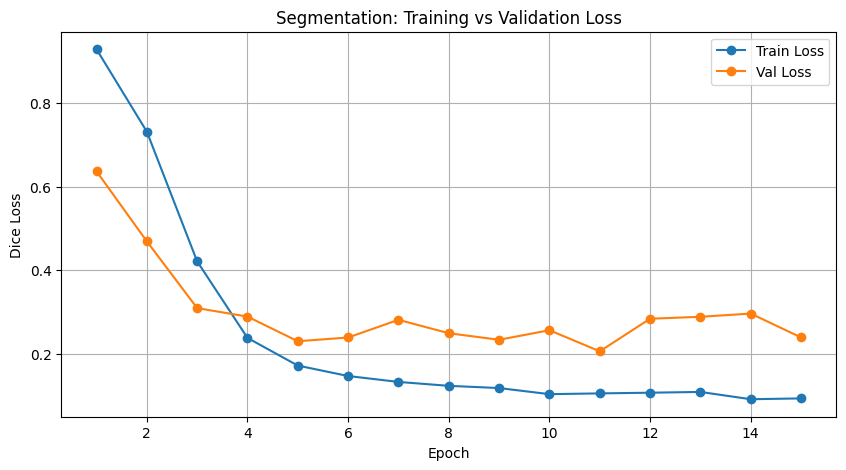

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS_SEG + 1), train_losses_seg, label="Train Loss", marker="o")
plt.plot(range(1, NUM_EPOCHS_SEG + 1), val_losses_seg, label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Dice Loss")
plt.title("Segmentation: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
best_unet = build_unet(encoder_name="resnet34", in_channels=3, out_channels=1)
best_unet = best_unet.to(device)
best_unet.load_state_dict(torch.load(checkpoint_path_seg))
best_unet.eval()

dice_metric = smp.losses.DiceLoss(mode="binary")

total_dice_score = 0.0
total_iou_score = 0.0
num_batches = 0

with torch.no_grad():
    for images, masks in test_seg_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = best_unet(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        intersection = (preds * masks).sum(dim=(1, 2, 3))
        union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
        dice_batch = (2 * intersection + 1e-7) / (union + 1e-7)

        pred_area = preds.sum(dim=(1, 2, 3))
        mask_area = masks.sum(dim=(1, 2, 3))
        overlap = intersection
        iou_batch = (overlap + 1e-7) / (pred_area + mask_area - overlap + 1e-7)

        total_dice_score += dice_batch.mean().item()
        total_iou_score += iou_batch.mean().item()
        num_batches += 1

avg_dice = total_dice_score / num_batches
avg_iou = total_iou_score / num_batches

print(f"Average Dice Score: {avg_dice:.4f}")
print(f"Average IoU Score: {avg_iou:.4f}")

Average Dice Score: 0.8788
Average IoU Score: 0.8423


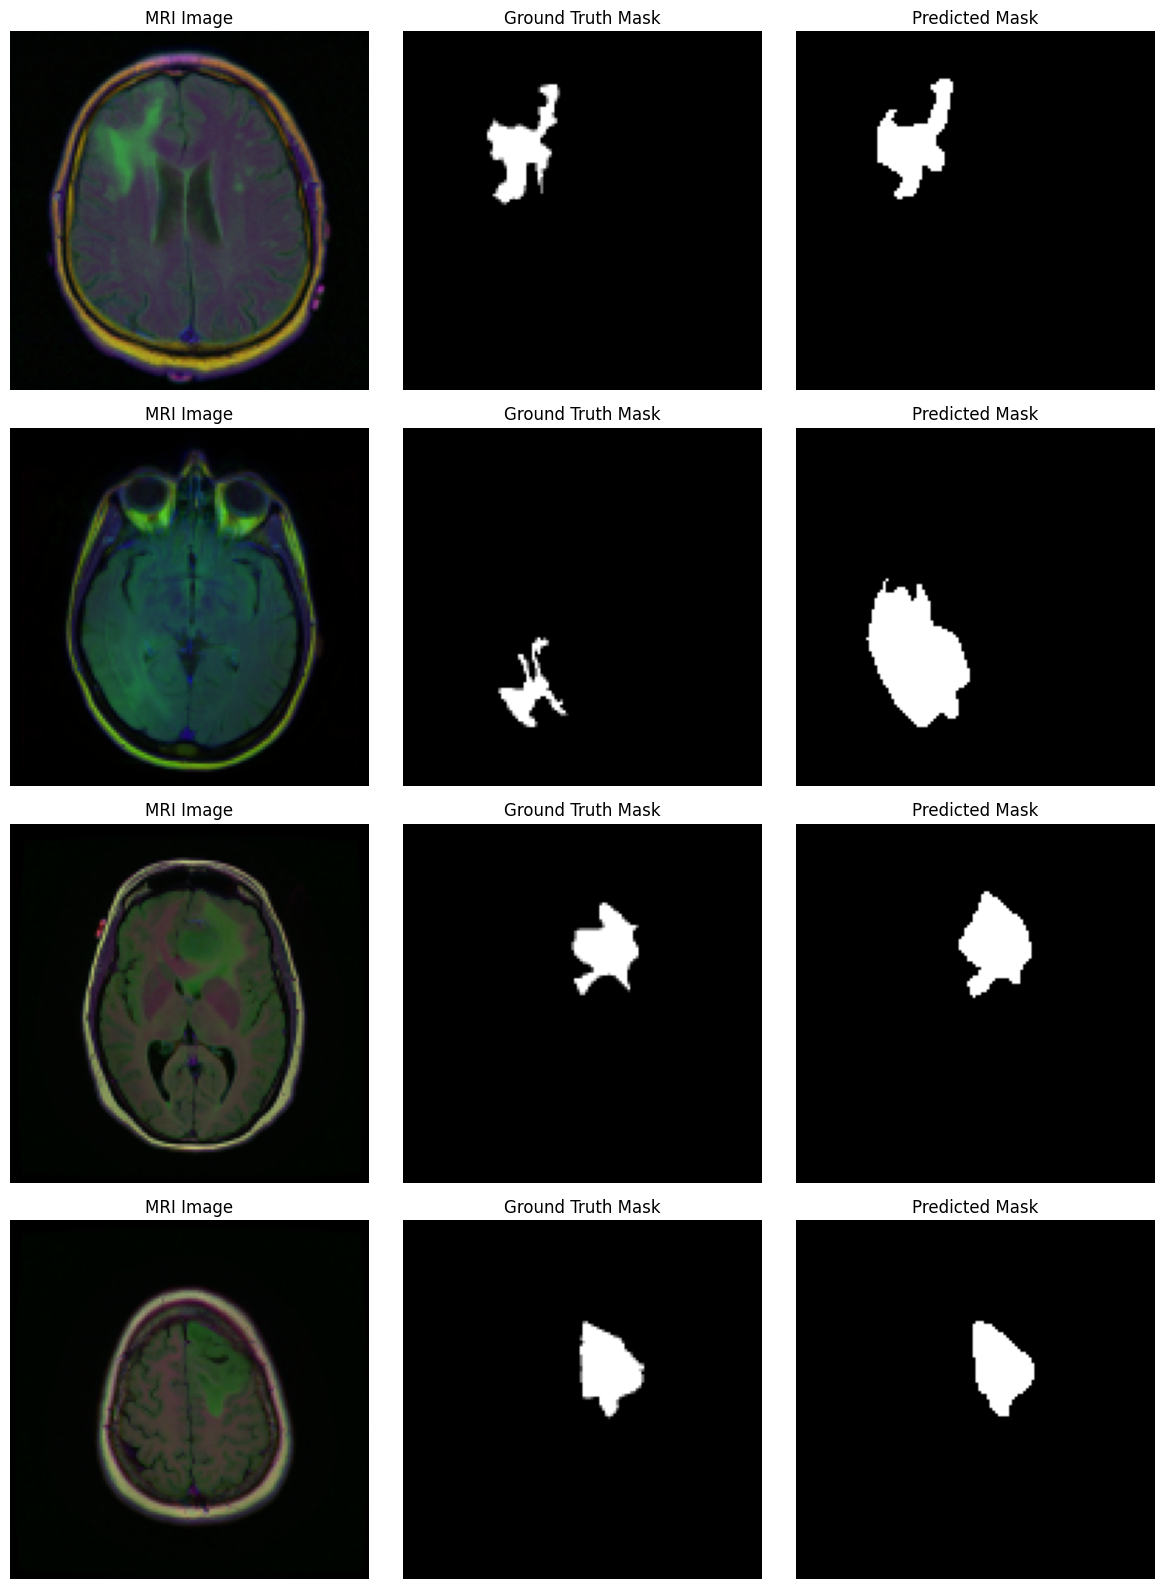

In [28]:
tumor_test_rows = test_df[test_df["has_tumor"] == True].reset_index(drop=True)
sample_indices = [5, 15, 25, 35]

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))

for row_idx, i in enumerate(sample_indices):
    row = tumor_test_rows.iloc[i]

    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image, (128, 128))

    mask_true = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask_true = cv2.resize(mask_true, (128, 128))

    image_input = image_resized.astype(np.float32) / 255.0
    image_input = np.transpose(image_input, (2, 0, 1))
    image_tensor = torch.tensor(image_input, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        output = best_unet(image_tensor)
        prob = torch.sigmoid(output)
        pred_mask = (prob > 0.5).float().cpu().numpy().squeeze()

    axes[row_idx, 0].imshow(image_resized)
    axes[row_idx, 0].set_title("MRI Image")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask_true, cmap="gray")
    axes[row_idx, 1].set_title("Ground Truth Mask")
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(pred_mask, cmap="gray")
    axes[row_idx, 2].set_title("Predicted Mask")
    axes[row_idx, 2].axis("off")

plt.tight_layout()
plt.savefig("../outputs/figures/segmentation_predictions_sample.png", dpi=150)
plt.show()